# Customer Engagement and Product Utilization Analytics for Retention Strategy

This notebook analyzes customer churn at a European bank through the lens of engagement and product usage, rather than demographics alone. The goal is to identify which customer behaviors are most strongly associated with retention, and to surface high value customers who are at risk of leaving despite appearing financially strong.

The analysis is organized into the following phases:

1. Data Ingestion and Validation
2. Engagement Classification
3. Product Utilization Analysis
4. Financial Commitment versus Engagement Analysis
5. Retention Strength Assessment
6. Key Performance Indicator Calculation

Each phase builds on the previous one, and every code cell is followed or preceded by an explanation of what it does and why it is used.

## Phase 1: Data Ingestion and Validation

Before any analysis can be trusted, the raw data must be loaded and checked for problems. This phase has four goals: load the dataset into memory, confirm that the columns contain the data types we expect, check for missing or duplicate records, and verify that the binary and categorical columns only contain valid values. Skipping this step is risky because errors discovered later, after analysis has already been built on top of bad data, are far more expensive to fix.

### Importing required libraries

The cell below imports the Python libraries used throughout this notebook.

`pandas` is a data analysis library that provides the DataFrame, a table like structure used to store and manipulate the customer dataset. `numpy` is a numerical computing library that pandas relies on internally, and which we use directly for some numerical operations. `matplotlib.pyplot` and `seaborn` are plotting libraries used to create static charts for exploratory analysis. `warnings` is a standard Python module, and we use it here to silence non critical warning messages so the notebook output stays clean and readable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Setting a consistent visual style for all plots in this notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Loading the dataset

The cell below reads the CSV file `European_Bank.csv` into a pandas DataFrame called `df`. A DataFrame is the primary data structure used in pandas; it stores data in rows and columns, similar to a spreadsheet, and allows fast filtering, grouping, and computation. The `.shape` attribute returns a tuple showing the number of rows and columns, which gives an immediate sense of the size of the dataset. The `.head()` method displays the first five rows so we can visually confirm the data loaded correctly and see what the columns look like.

In [2]:
df = pd.read_csv('European_Bank.csv')

print('Dataset shape (rows, columns):', df.shape)
df.head()

Dataset shape (rows, columns): (10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Checking data types and structure

The `.info()` method prints a summary of the DataFrame, including the name of each column, how many non null values it contains, and its data type. This is important because it lets us confirm that numeric columns such as `Age` and `Balance` are actually stored as numbers, and not accidentally read in as text, which would break later calculations.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


### Checking for missing values

The `.isnull()` method returns a DataFrame of the same shape as `df`, but filled with `True` where a value is missing and `False` where it is present. Chaining `.sum()` after it adds up the `True` values in each column, giving a count of missing values per column. If any column shows a count greater than zero, we would need to decide whether to fill in those missing values or remove the affected rows before proceeding. A column with all zeros means the dataset is complete for that column.

In [4]:
missing_values = df.isnull().sum()
print('Missing values per column:')
print(missing_values)

Missing values per column:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


### Checking for duplicate customers

Each customer should appear only once in the dataset, identified uniquely by `CustomerId`. The `.duplicated()` method checks each value in the `CustomerId` column and marks it `True` if that value has already appeared earlier in the column. Summing this with `.sum()` gives the total count of duplicate customer records. A result of zero confirms that every customer is represented exactly once, which is important because duplicate records would artificially inflate or distort any statistics we calculate later, such as churn rate.

In [5]:
duplicate_customers = df['CustomerId'].duplicated().sum()
print('Number of duplicate CustomerId records:', duplicate_customers)

Number of duplicate CustomerId records: 0


### Validating binary and categorical columns

Several columns in this dataset are meant to hold only specific values. `HasCrCard`, `IsActiveMember`, and `Exited` are binary flags, meaning they should only ever contain 0 or 1. `Geography` should only contain the three country names mentioned in the project guidelines, and `Gender` should only contain two categories. The `.unique()` method returns an array of every distinct value found in a column, without repetition. Printing these arrays lets us visually confirm that no unexpected or invalid values, such as a typo or a missing category, have slipped into the data.

In [6]:
print('Unique values in HasCrCard:', df['HasCrCard'].unique())
print('Unique values in IsActiveMember:', df['IsActiveMember'].unique())
print('Unique values in Exited:', df['Exited'].unique())
print('Unique values in Geography:', df['Geography'].unique())
print('Unique values in Gender:', df['Gender'].unique())
print('Unique values in NumOfProducts:', sorted(df['NumOfProducts'].unique()))

Unique values in HasCrCard: [1 0]
Unique values in IsActiveMember: [1 0]
Unique values in Exited: [1 0]
Unique values in Geography: <StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str
Unique values in Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Unique values in NumOfProducts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### Reviewing the Year column

The dataset contains a `Year` column that was not part of the original project guidelines. Before deciding whether to use or drop it, we check how many distinct values it holds. If it turns out to hold only a single value across all 10,000 rows, it carries no information for our analysis, since a column that never changes cannot help explain differences in customer behavior. In that case we will exclude it from further analysis, though it can still be kept in the raw dataset for reference.

In [7]:
print('Unique values in Year:', df['Year'].unique())

Unique values in Year: [2025]


### Descriptive statistics for numeric columns

The `.describe()` method calculates summary statistics, count, mean, standard deviation, minimum, maximum, and the 25th, 50th, and 75th percentiles, for every numeric column in the DataFrame. This gives a quick sense of the scale and spread of each variable. For example, checking the minimum and maximum of `Age` and `CreditScore` helps confirm there are no impossible values, such as a negative age or a credit score outside a realistic range. The `.T` at the end transposes the output, swapping rows and columns, which makes the table easier to read when there are many columns.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2.025000e+03,0.000000,2025.00,2025.00,2.025000e+03,2.025000e+03,2025.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


### Confirming the overall churn rate

`Exited` is the target column, where 1 means the customer has churned and 0 means the customer is retained. Taking the `.mean()` of a column made up only of 0s and 1s gives the proportion of 1s, which is exactly the overall churn rate. Multiplying by 100 converts this proportion into a percentage. This single number becomes our baseline; every deeper pattern we find later, such as the churn rate within a specific engagement group, will be compared back against this overall figure to judge whether that group is better or worse than average.

In [9]:
overall_churn_rate = df['Exited'].mean() * 100
print(f'Overall churn rate: {overall_churn_rate:.2f}%')

Overall churn rate: 20.37%


### Phase 1 summary

The dataset contains 10,000 customer records across 14 columns, with no missing values and no duplicate customer records. All binary columns, `HasCrCard`, `IsActiveMember`, and `Exited`, contain only the values 0 and 1 as expected. `Geography` contains exactly the three expected countries, and `Gender` contains exactly two expected categories. `NumOfProducts` ranges from 1 to 4. The `Year` column was found to contain a single constant value across all rows, so it will be excluded from further analysis since it cannot explain any variation in customer behavior. The overall churn rate serves as the baseline against which every later comparison in this notebook will be measured.

With the data validated, the next phase will classify each customer into an engagement profile based on their activity status and product usage.

## Phase 2: Engagement Classification

The project guidelines ask us to group customers into four engagement profiles: active engaged customers, inactive disengaged customers, active but low-product customers, and inactive high-balance customers. These profiles combine two pieces of information: whether the customer is active (`IsActiveMember`) and how deep their relationship with the bank is, measured either by the number of products they hold (`NumOfProducts`) or by their account balance (`Balance`).

To make sure every customer falls into exactly one profile, we apply the following rule, checked in order:

1. If the customer is active and holds two or more products, they are classified as **Active Engaged**.
2. If the customer is active but holds only one product, they are classified as **Active Low-Product**.
3. If the customer is inactive and their balance is above the median balance of all customers, they are classified as **Inactive High-Balance**.
4. Otherwise, meaning the customer is inactive and their balance is at or below the median, they are classified as **Inactive Disengaged**.

This ordering matters because it resolves overlaps. For example, an inactive customer with two products is still inactive, so activity status is checked first, and only inactive customers are then split further by balance.

### Calculating the balance threshold

Before we can label a customer as "high balance", we need a cutoff value to compare against. The cell below calculates the median balance across all 10,000 customers using the `.median()` method. The median, the middle value when all balances are sorted, is used instead of the mean because `Balance` contains many customers with a value of exactly 0, which would pull the mean down and make it a less representative cutoff. The median is more robust to this kind of skew.

In [10]:
balance_threshold = df['Balance'].median()
print(f'Median balance (used as the high-balance threshold): {balance_threshold:,.2f}')

Median balance (used as the high-balance threshold): 97,198.54


### Assigning engagement profiles

The function below implements the four-step rule described above. It takes a single row of the DataFrame as input and returns a text label. `IsActiveMember` is checked first using an `if` statement; if it equals 1, the customer is active, and we then check `NumOfProducts` to decide between "Active Engaged" and "Active Low-Product". If `IsActiveMember` equals 0, the customer is inactive, and we instead check their `Balance` against the `balance_threshold` calculated above to decide between "Inactive High-Balance" and "Inactive Disengaged".

The `.apply()` method then runs this function once for every row in the DataFrame, with `axis=1` telling pandas to pass entire rows rather than individual columns. The result is stored in a new column called `EngagementProfile`.

In [11]:
def classify_engagement(row):
    if row['IsActiveMember'] == 1:
        if row['NumOfProducts'] >= 2:
            return 'Active Engaged'
        else:
            return 'Active Low-Product'
    else:
        if row['Balance'] > balance_threshold:
            return 'Inactive High-Balance'
        else:
            return 'Inactive Disengaged'

df['EngagementProfile'] = df.apply(classify_engagement, axis=1)

# Displaying how many customers fall into each profile
df['EngagementProfile'].value_counts()

EngagementProfile
Active Engaged           2588
Active Low-Product       2563
Inactive High-Balance    2456
Inactive Disengaged      2393
Name: count, dtype: int64

### Churn rate by engagement profile

Now that every customer has an `EngagementProfile` label, we group the data by that column using `.groupby()` and calculate the mean of `Exited` within each group. Since `Exited` only contains 0 and 1, this mean is exactly the churn rate for that profile, expressed as a proportion. Multiplying by 100 converts it to a percentage, and `.round(2)` rounds the result to two decimal places for readability. The `.sort_values(ascending=False)` call orders the profiles from highest to lowest churn rate, so the riskiest group appears first.

In [12]:
churn_by_profile = (df.groupby('EngagementProfile')['Exited'].mean() * 100).round(2)
churn_by_profile = churn_by_profile.sort_values(ascending=False)

print('Churn rate by engagement profile (%):')
print(churn_by_profile)

Churn rate by engagement profile (%):


EngagementProfile
Inactive High-Balance    32.33
Inactive Disengaged      21.23
Active Low-Product       18.92
Active Engaged            9.66
Name: Exited, dtype: float64


### Visualizing churn rate by engagement profile

A bar chart makes it easier to compare churn rates across the four profiles at a glance. `plt.figure()` creates a new figure with the given size. `sns.barplot()` draws the bars, taking the profile names as the x-axis and their churn rates as the y-axis. The `palette` argument assigns a color gradient so that higher churn rates stand out visually. `plt.axhline()` draws a horizontal dashed line at the overall churn rate calculated in Phase 1, giving a clear visual baseline to compare each profile against. The remaining lines add a title, axis labels, and rotate the x-axis labels slightly so long profile names do not overlap.

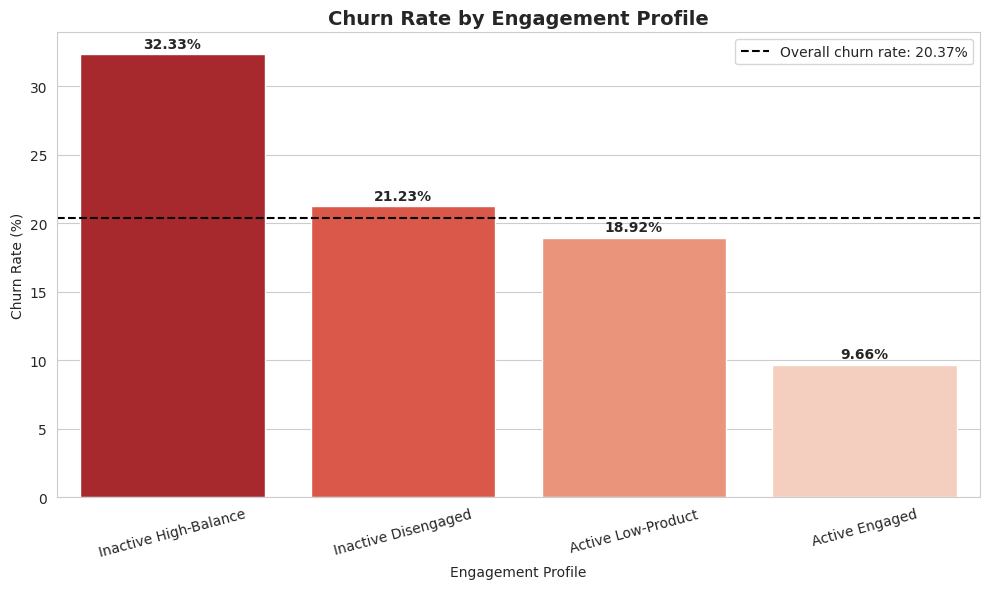

In [13]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=churn_by_profile.index, y=churn_by_profile.values, palette='Reds_r')
plt.axhline(overall_churn_rate, color='black', linestyle='--', label=f'Overall churn rate: {overall_churn_rate:.2f}%')

plt.title('Churn Rate by Engagement Profile', fontsize=14, fontweight='bold')
plt.xlabel('Engagement Profile')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.legend()

# Adding the exact percentage value on top of each bar for precise reading
for i, value in enumerate(churn_by_profile.values):
    ax.text(i, value + 0.5, f'{value}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Phase 2 summary

Every customer has now been assigned to one of four engagement profiles, using activity status as the primary split and either product count or balance as the secondary split. The churn rate calculated for each profile can be compared directly against the overall baseline established in Phase 1. The profile with the highest churn rate represents the group the bank should prioritize for retention efforts, while the profile with the lowest churn rate represents the customer relationship pattern the bank should aim to replicate more broadly.

The next phase examines product utilization more closely, looking at how the number of products alone, independent of activity status, relates to churn.

## Phase 3: Product Utilization Analysis

This phase looks at `NumOfProducts` on its own, separate from activity status, to understand how the depth of a customer's product relationship with the bank relates to churn. The guidelines ask for three things: the churn rate at each individual product count, a comparison between single-product and multi-product customers, and an overall assessment of whether holding more products makes a customer more loyal.

### Churn rate by number of products

The cell below groups the data by `NumOfProducts` and calculates two things for each group using `.agg()`: `count`, the number of customers holding that many products, and `mean`, which as before gives the churn rate since `Exited` only contains 0 and 1. Passing a list of function names, `['count', 'mean']`, to `.agg()` lets us compute both statistics in a single pass over the data rather than running two separate `.groupby()` calls. The `mean` column is then multiplied by 100 and rounded, converting it into a readable percentage.

In [14]:
product_summary = df.groupby('NumOfProducts')['Exited'].agg(['count', 'mean'])
product_summary['mean'] = (product_summary['mean'] * 100).round(2)
product_summary.columns = ['CustomerCount', 'ChurnRate(%)']

print(product_summary)

               CustomerCount  ChurnRate(%)
NumOfProducts                             
1                       5084         27.71
2                       4590          7.58
3                        266         82.71
4                         60        100.00


### Visualizing churn rate against product count

This chart plots churn rate on the y-axis against the number of products on the x-axis, using `sns.barplot()` as before. If loyalty simply increased with more products, we would expect a smooth downward line as we move from 1 to 4 products. Any sharp reversal in that pattern, for example a spike in churn at 3 or 4 products, would be an important and non-obvious finding worth flagging clearly, since it would contradict the simple assumption that "more products always means more loyalty".

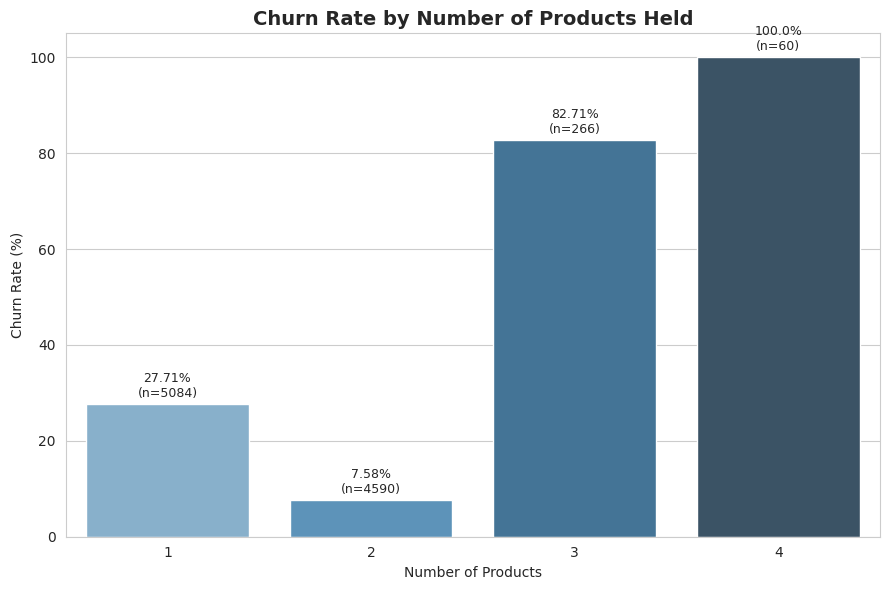

In [15]:
plt.figure(figsize=(9, 6))
ax = sns.barplot(x=product_summary.index, y=product_summary['ChurnRate(%)'], palette='Blues_d')

plt.title('Churn Rate by Number of Products Held', fontsize=14, fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')

# Adding the exact percentage value and the customer count above each bar,
# so both the risk level and how many customers it affects are visible together
for i, (rate, count) in enumerate(zip(product_summary['ChurnRate(%)'], product_summary['CustomerCount'])):
    ax.text(i, rate + 1.5, f'{rate}%\n(n={count})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Single-product versus multi-product retention

To directly answer the guideline's comparison between single-product and multi-product customers, we create a new column, `ProductGroup`, using `.apply()` with a small function passed inline as a `lambda`. A lambda is a short, unnamed function written on one line; here it checks whether `NumOfProducts` equals 1, and returns the label `'Single-Product'` if true, or `'Multi-Product'` otherwise. Grouping by this new column and taking the mean of `Exited` gives a simple two-way comparison.

In [16]:
df['ProductGroup'] = df['NumOfProducts'].apply(lambda x: 'Single-Product' if x == 1 else 'Multi-Product')

single_vs_multi = (df.groupby('ProductGroup')['Exited'].mean() * 100).round(2)
print('Churn rate: Single-Product vs Multi-Product (%)')
print(single_vs_multi)

Churn rate: Single-Product vs Multi-Product (%)
ProductGroup
Multi-Product     12.77
Single-Product    27.71
Name: Exited, dtype: float64


### Phase 3 summary

The relationship between product count and churn turns out not to be a simple straight line. Customers with 1 product churn at roughly 27.7%, and this drops sharply to 7.6% for customers with 2 products, confirming that a second product meaningfully strengthens the relationship. However, the pattern reverses dramatically at 3 products, where churn jumps to about 82.7%, and at 4 products, where every single customer in the dataset has churned, a 100% churn rate. These two groups are small, 266 and 60 customers respectively, but the effect is extreme and consistent.

This means "product depth" is not simply "more is better". The practical interpretation is that 2 products represents a genuine sweet spot for retention, while customers who end up holding 3 or 4 products behave more like a distinct at-risk segment, quite possibly customers who were aggressively cross-sold additional products, or who accumulated products shortly before leaving for unrelated reasons. This is exactly the kind of counter-intuitive, non-obvious pattern the project objectives asked us to surface, and it will need to be highlighted clearly in the final research paper and executive summary rather than buried in a single aggregate statistic.

The next phase looks at how account balance interacts with activity status, to identify high-value customers who may be quietly at risk of leaving.

## Phase 4: Financial Commitment versus Engagement Analysis

This phase tests the project's central hypothesis directly: does having money in the bank actually protect a customer from churning, or does engagement matter more than balance? Three things are examined here, following the guidelines: a cross-analysis of balance against activity status, detection of any mismatch between salary and balance, and identification of "at-risk premium customers", meaning financially valuable customers who show signs of disengagement.

### Balance versus activity cross-analysis

We first split customers into a `BalanceTier`, either `'High Balance'` if their balance is above the overall median, or `'Low/Zero Balance'` otherwise, using the same median threshold established in Phase 2. Grouping by both `BalanceTier` and `IsActiveMember` together, by passing a list of two column names to `.groupby()`, creates four combined groups. Calculating `count` and `mean` of `Exited` for each combination lets us see whether balance or activity status has the stronger influence on churn, and whether their effects combine.

In [17]:
df['BalanceTier'] = df['Balance'].apply(lambda x: 'High Balance' if x > balance_threshold else 'Low/Zero Balance')

balance_activity_cross = df.groupby(['BalanceTier', 'IsActiveMember'])['Exited'].agg(['count', 'mean'])
balance_activity_cross['mean'] = (balance_activity_cross['mean'] * 100).round(2)
balance_activity_cross.columns = ['CustomerCount', 'ChurnRate(%)']

print(balance_activity_cross)

                                 CustomerCount  ChurnRate(%)
BalanceTier      IsActiveMember                             
High Balance     0                        2456         32.33
                 1                        2544         17.89
Low/Zero Balance 0                        2393         21.23
                 1                        2607         10.74


### Detecting salary-balance mismatch

A "mismatch" here means a customer whose salary level and balance level point in different directions, for example someone with a high estimated salary but a surprisingly low balance, which could suggest they keep most of their money elsewhere. The function below compares both `EstimatedSalary` and `Balance` against their respective medians and assigns one of four labels covering every combination of high or low salary with high or low balance. As before, `.apply()` with `axis=1` runs this function once per row, and the result becomes a new column, `SalaryBalanceGroup`.

In [18]:
salary_threshold = df['EstimatedSalary'].median()

def classify_salary_balance(row):
    high_salary = row['EstimatedSalary'] > salary_threshold
    high_balance = row['Balance'] > balance_threshold

    if high_salary and not high_balance:
        return 'High Salary, Low Balance'
    elif not high_salary and high_balance:
        return 'Low Salary, High Balance'
    elif high_salary and high_balance:
        return 'High Salary, High Balance'
    else:
        return 'Low Salary, Low Balance'

df['SalaryBalanceGroup'] = df.apply(classify_salary_balance, axis=1)

salary_balance_summary = df.groupby('SalaryBalanceGroup')['Exited'].agg(['count', 'mean'])
salary_balance_summary['mean'] = (salary_balance_summary['mean'] * 100).round(2)
salary_balance_summary.columns = ['CustomerCount', 'ChurnRate(%)']

print(salary_balance_summary.sort_values('ChurnRate(%)', ascending=False))

                           CustomerCount  ChurnRate(%)
SalaryBalanceGroup                                    
High Salary, High Balance           2516         25.08
Low Salary, High Balance            2484         24.88
High Salary, Low Balance            2484         16.55
Low Salary, Low Balance             2516         14.98


### Identifying at-risk premium customers

"Premium" customers are defined here as the top 25 percent of the customer base by balance. The `.quantile(0.75)` method calculates the value below which 75 percent of balances fall, which is exactly the cutoff for the top quarter. Among these premium customers, the ones who are also inactive, `IsActiveMember == 0`, represent the "at-risk premium" segment described in the project background: customers who look financially strong but show no sign of active engagement with the bank. We compare the churn rate of this at-risk subgroup against the churn rate of the full premium group to quantify exactly how much extra risk inactivity adds even among the bank's most valuable customers.

In [19]:
premium_threshold = df['Balance'].quantile(0.75)

premium_customers = df[df['Balance'] > premium_threshold]
at_risk_premium = premium_customers[premium_customers['IsActiveMember'] == 0]

print(f'Premium balance threshold (75th percentile): {premium_threshold:,.2f}')
print(f'Total premium customers: {len(premium_customers)}')
print(f'Premium customer overall churn rate: {premium_customers["Exited"].mean() * 100:.2f}%')
print()
print(f'At-risk premium customers (premium and inactive): {len(at_risk_premium)}')
print(f'At-risk premium churn rate: {at_risk_premium["Exited"].mean() * 100:.2f}%')

Premium balance threshold (75th percentile): 127,644.24
Total premium customers: 2500
Premium customer overall churn rate: 23.68%

At-risk premium customers (premium and inactive): 1247
At-risk premium churn rate: 30.47%


### Visualizing the balance and activity interaction

A grouped bar chart makes the four-way comparison from the cross-analysis easier to read than a table. `.unstack()` reshapes the `balance_activity_cross` table so that `IsActiveMember` becomes separate columns instead of an extra row index level, which is the format `.plot(kind='bar')` expects to draw grouped bars side by side automatically. This visually confirms whether the gap between active and inactive churn holds steady, widens, or narrows as balance increases.

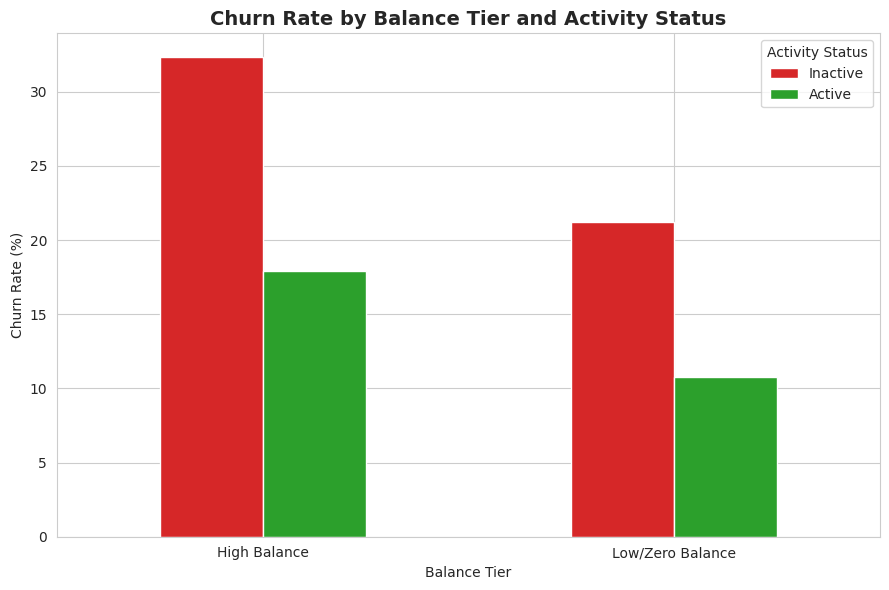

In [20]:
plot_data = balance_activity_cross['ChurnRate(%)'].unstack()
plot_data.columns = ['Inactive', 'Active']

ax = plot_data.plot(kind='bar', figsize=(9, 6), color=['#d62728', '#2ca02c'])
plt.title('Churn Rate by Balance Tier and Activity Status', fontsize=14, fontweight='bold')
plt.xlabel('Balance Tier')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Activity Status')
plt.tight_layout()
plt.show()

### Phase 4 summary

The cross-analysis shows that activity status changes churn risk by roughly the same margin regardless of balance tier: among high balance customers, churn nearly doubles from 17.9% when active to 32.3% when inactive, and among low balance customers it doubles from about 10.7% to 21.2%. This confirms that engagement, not balance, is the dominant factor, since the inactive high balance group is the single worst combination at 32.3% churn, higher than any low balance group.

The salary-balance mismatch analysis reveals something notable: churn tracks balance level far more closely than salary level. Both high balance groups churn at around 25%, regardless of whether salary is high or low, while both low balance groups churn at around 15%, again regardless of salary. This suggests that `EstimatedSalary` on its own is a weak predictor of churn, and that `Balance`, likely because it reflects actual money kept with the bank rather than income earned elsewhere, is the more meaningful financial signal.

The at-risk premium segment, the top 25% of customers by balance who are also inactive, contains 1,247 customers with a churn rate of 30.5%, noticeably higher than the 23.7% churn rate across all premium customers. This is a concrete, actionable finding: nearly a third of the bank's most valuable but disengaged customers are likely to leave, representing significant revenue at risk that a balance-only view of customer health would miss entirely.

The next phase brings these findings together to define what a genuinely "sticky", low-churn customer looks like, and to test whether engagement effects hold consistently across different customer segments.

## Phase 5: Retention Strength Assessment

This phase brings together the engagement work from Phase 2 with a new variable, `Tenure`, the number of years a customer has been with the bank, to answer three questions from the guidelines: what does a genuinely "sticky", low-churn customer look like, does the churn rate within each engagement profile stay stable no matter how long someone has been a customer, and where exactly do the thresholds sit that separate low-risk customers from high-risk ones.

### Checking whether tenure alone predicts churn

Before testing stability across engagement tiers, we first check whether `Tenure` by itself has any real relationship with churn. Grouping by `Tenure` and calculating `count` and `mean` of `Exited`, exactly as in earlier phases, shows the churn rate at each individual year of tenure, from new customers at 0 years to long-standing customers at 10 years.

In [21]:
tenure_summary = df.groupby('Tenure')['Exited'].agg(['count', 'mean'])
tenure_summary['mean'] = (tenure_summary['mean'] * 100).round(2)
tenure_summary.columns = ['CustomerCount', 'ChurnRate(%)']

print(tenure_summary)

        CustomerCount  ChurnRate(%)
Tenure                             
0                 413         23.00
1                1035         22.42
2                1048         19.18
3                1009         21.11
4                 989         20.53
5                1012         20.65
6                 967         20.27
7                1028         17.22
8                1025         19.22
9                 984         21.65
10                490         20.61


### Grouping tenure into readable buckets

Individual year-by-year tenure is noisy and hard to read as a trend. The `pd.cut()` function groups the continuous `Tenure` values into four broader buckets, defined by the `bins` argument: 0 to 2 years, 3 to 5 years, 6 to 8 years, and 9 to 10 years. The `labels` argument assigns a readable name to each bucket. This creates a new column, `TenureBucket`, which is easier to group and plot than eleven separate tenure values.

In [22]:
df['TenureBucket'] = pd.cut(
    df['Tenure'],
    bins=[-1, 2, 5, 8, 10],
    labels=['0-2 yrs', '3-5 yrs', '6-8 yrs', '9-10 yrs']
)

tenure_bucket_churn = (df.groupby('TenureBucket')['Exited'].mean() * 100).round(2)
print('Churn rate by tenure bucket (%):')
print(tenure_bucket_churn)

Churn rate by tenure bucket (%):
TenureBucket
0-2 yrs     21.15
3-5 yrs     20.76
6-8 yrs     18.87
9-10 yrs    21.30
Name: Exited, dtype: float64


### Measuring churn stability across engagement tiers

This is the central test of this phase: does each engagement profile's churn rate stay roughly constant across all four tenure buckets, or does it drift as customers age with the bank? Grouping by both `EngagementProfile` and `TenureBucket` together produces the churn rate for every combination of the two, letting us read across each row of the resulting table to see how stable, or unstable, that profile's risk level is over time. `.round(3)` keeps the output as a proportion with three decimal places rather than converting to a percentage, since we are focused on comparing small differences within each profile here.

In [23]:
stability_check = df.groupby(['EngagementProfile', 'TenureBucket'])['Exited'].mean().round(3)
stability_table = stability_check.unstack()

print('Churn rate by Engagement Profile across Tenure Buckets:')
print(stability_table)

Churn rate by Engagement Profile across Tenure Buckets:
TenureBucket           0-2 yrs  3-5 yrs  6-8 yrs  9-10 yrs
EngagementProfile                                         
Active Engaged           0.093    0.099    0.093     0.106
Active Low-Product       0.204    0.196    0.178     0.171
Inactive Disengaged      0.211    0.242    0.187     0.202
Inactive High-Balance    0.357    0.297    0.303     0.361


### Visualizing engagement stability over tenure

Plotting each engagement profile as its own line across the four tenure buckets makes stability, or the lack of it, immediately visible. Flat, roughly horizontal lines indicate that a profile's risk level is a stable trait of the customer, independent of how long they have banked with the institution. Lines that slope up or down, or cross over other lines, would indicate that tenure changes the risk associated with that profile.

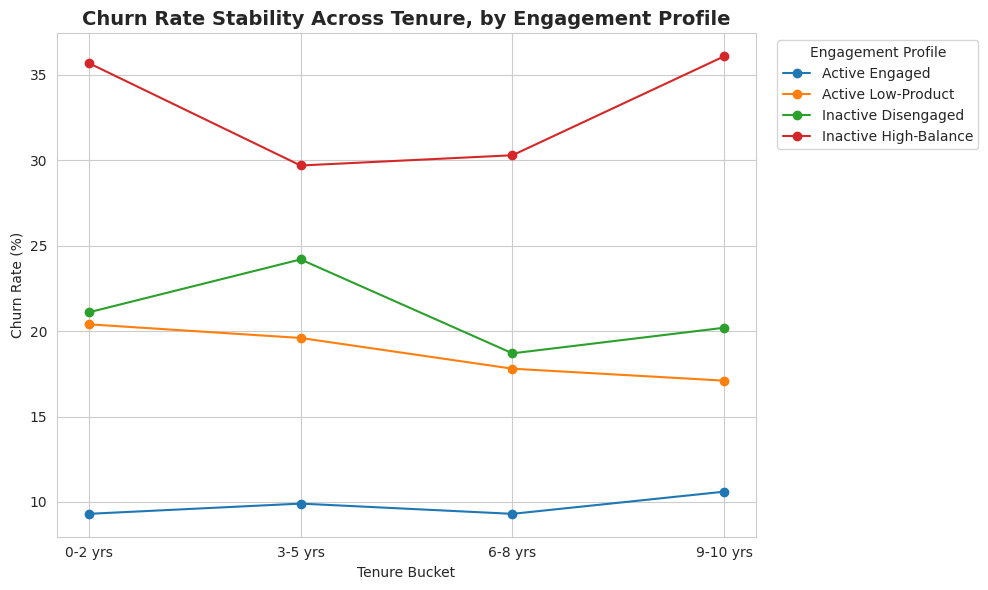

In [24]:
plt.figure(figsize=(10, 6))

for profile in stability_table.index:
    plt.plot(stability_table.columns, stability_table.loc[profile] * 100, marker='o', label=profile)

plt.title('Churn Rate Stability Across Tenure, by Engagement Profile', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Bucket')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Engagement Profile', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Defining a sticky customer profile

Based on every finding so far, active engagement and holding a credit card have both shown a meaningful association with lower churn. We define a "sticky customer" as one who satisfies both conditions at once: belonging to the `Active Engaged` profile from Phase 2, meaning they are active and hold two or more products, and also holding a credit card, `HasCrCard == 1`. The two conditions are combined with the `&` operator, which performs a logical AND comparison element by element across the DataFrame, and `.astype(int)` converts the resulting `True`/`False` values into 1s and 0s stored in a new column, `Sticky`.

In [25]:
df['Sticky'] = ((df['EngagementProfile'] == 'Active Engaged') & (df['HasCrCard'] == 1)).astype(int)

sticky_summary = df.groupby('Sticky')['Exited'].agg(['count', 'mean'])
sticky_summary['mean'] = (sticky_summary['mean'] * 100).round(2)
sticky_summary.columns = ['CustomerCount', 'ChurnRate(%)']
sticky_summary.index = ['Not Sticky', 'Sticky']

print(sticky_summary)

            CustomerCount  ChurnRate(%)
Not Sticky           8168         22.89
Sticky               1832          9.12


### Phase 5 summary

Tenure alone turns out to be a weak predictor of churn: the churn rate stays within a narrow band of roughly 19% to 23% across every tenure bucket, from brand new customers to those who have been with the bank for nine or ten years, with no clear upward or downward trend. This is itself a useful finding, since it means retention risk is not something that naturally fades with customer age, and long-tenured customers cannot be assumed to be safe.

The stability check across engagement profiles is more revealing. Within each profile, the churn rate stays remarkably consistent across all four tenure buckets. The `Active Engaged` profile holds steady at roughly 9 to 11% churn regardless of tenure, while the `Inactive High-Balance` profile holds steady at a much higher 30 to 36% churn, also regardless of tenure. This confirms that engagement profile, not how long someone has been a customer, is the stable and reliable signal of retention risk.

The "sticky customer" definition, active engagement combined with credit card ownership, identifies 1,832 customers with a churn rate of just 9.12%, compared to 22.89% for everyone else. This is a strong, easily explainable profile for the bank to define its most loyal segment by, and one it should try to grow through targeted product bundling and engagement campaigns.

The final phase now formalizes these findings into the five KPIs specified in the project guidelines, which will feed directly into the Streamlit dashboard, research paper, and executive summary.

## Phase 6: Key Performance Indicator Calculation

This final analytical phase formalizes the patterns found in Phases 2 through 5 into five specific KPIs requested by the project guidelines. Each KPI is a single, clearly defined number that summarizes one aspect of the engagement and retention story, and each is built directly on calculations already performed earlier in this notebook, so the KPIs stay consistent with everything shown so far rather than introducing new, unexplained numbers.

### KPI 1: Engagement Retention Ratio

This KPI answers the question: how many times more likely is an inactive customer to churn compared to an active one? It is calculated by dividing the churn rate of inactive customers by the churn rate of active customers. A value of 1 would mean activity status makes no difference. A value greater than 1 means inactive customers churn more often, and the size of the number shows by how large a multiple.

In [26]:
active_churn_rate = df[df['IsActiveMember'] == 1]['Exited'].mean()
inactive_churn_rate = df[df['IsActiveMember'] == 0]['Exited'].mean()

engagement_retention_ratio = inactive_churn_rate / active_churn_rate

print(f'Active member churn rate: {active_churn_rate * 100:.2f}%')
print(f'Inactive member churn rate: {inactive_churn_rate * 100:.2f}%')
print(f'Engagement Retention Ratio: {engagement_retention_ratio:.2f}')
print(f'Interpretation: Inactive customers are {engagement_retention_ratio:.2f} times more likely to churn than active customers.')

Active member churn rate: 14.27%
Inactive member churn rate: 26.85%
Engagement Retention Ratio: 1.88
Interpretation: Inactive customers are 1.88 times more likely to churn than active customers.


### KPI 2: Product Depth Index

This KPI measures how much churn improves when a customer moves from holding a single product to holding two products, which Phase 3 identified as the genuine retention sweet spot. It is calculated as the percentage reduction in churn rate between one-product and two-product customers: the difference between the two churn rates, divided by the one-product churn rate, expressed as a percentage. We deliberately compare 1 versus 2 products rather than including 3 and 4 products in this particular KPI, because Phase 3 showed that 3 and 4 product customers behave as a distinct at-risk segment rather than continuing the loyalty trend, and folding them in would misleadingly cancel out the strong 1-to-2 product effect.

In [27]:
churn_1_product = df[df['NumOfProducts'] == 1]['Exited'].mean()
churn_2_products = df[df['NumOfProducts'] == 2]['Exited'].mean()

product_depth_index = ((churn_1_product - churn_2_products) / churn_1_product) * 100

print(f'Churn rate, 1 product: {churn_1_product * 100:.2f}%')
print(f'Churn rate, 2 products: {churn_2_products * 100:.2f}%')
print(f'Product Depth Index: {product_depth_index:.2f}%')
print(f'Interpretation: Moving from 1 to 2 products reduces churn risk by {product_depth_index:.2f}%.')

Churn rate, 1 product: 27.71%
Churn rate, 2 products: 7.58%
Product Depth Index: 72.64%
Interpretation: Moving from 1 to 2 products reduces churn risk by 72.64%.


### KPI 3: High-Balance Disengagement Rate

This KPI measures what proportion of the bank's high-balance customers, those above the median balance, are inactive. It does not measure churn directly; instead it measures exposure, meaning how large the pool of "premium but disengaged" customers is. Even if this group's churn rate were only moderate, a high disengagement rate would mean a large number of valuable customers are quietly at risk. It is calculated by filtering to customers above the balance threshold, then taking the proportion of that filtered group where `IsActiveMember` equals 0.

In [28]:
high_balance_customers = df[df['Balance'] > balance_threshold]
high_balance_disengagement_rate = (high_balance_customers['IsActiveMember'] == 0).mean() * 100

print(f'Total high-balance customers: {len(high_balance_customers)}')
print(f'High-Balance Disengagement Rate: {high_balance_disengagement_rate:.2f}%')
print(f'Interpretation: {high_balance_disengagement_rate:.2f}% of the bank\'s high-balance customers are currently inactive.')

Total high-balance customers: 5000
High-Balance Disengagement Rate: 49.12%
Interpretation: 49.12% of the bank's high-balance customers are currently inactive.


### KPI 4: Credit Card Stickiness Score

This KPI tests whether holding a credit card is associated with lower churn, following the same percentage-reduction logic as the Product Depth Index. It is calculated as the percentage reduction in churn rate between customers without a credit card and customers with one. Unlike the previous KPIs, this result should be read carefully rather than assumed to be strong, since the guidelines only asked us to measure the relationship, not to assume it is significant.

In [29]:
churn_with_card = df[df['HasCrCard'] == 1]['Exited'].mean()
churn_without_card = df[df['HasCrCard'] == 0]['Exited'].mean()

credit_card_stickiness_score = ((churn_without_card - churn_with_card) / churn_without_card) * 100

print(f'Churn rate, with credit card: {churn_with_card * 100:.2f}%')
print(f'Churn rate, without credit card: {churn_without_card * 100:.2f}%')
print(f'Credit Card Stickiness Score: {credit_card_stickiness_score:.2f}%')
print(f'Interpretation: Holding a credit card is associated with only a {credit_card_stickiness_score:.2f}% reduction in churn, a weak effect on its own.')

Churn rate, with credit card: 20.18%
Churn rate, without credit card: 20.81%
Credit Card Stickiness Score: 3.03%
Interpretation: Holding a credit card is associated with only a 3.03% reduction in churn, a weak effect on its own.


### KPI 5: Relationship Strength Index

This final KPI combines three positive engagement signals into a single composite score per customer, ranging from 0 to 3: one point for being an active member, one point for holding two or more products, and one point for holding a credit card. Each condition is evaluated separately and produces a `True` or `False` value; adding them together with the `+` operator works because Python treats `True` as 1 and `False` as 0 in arithmetic, so the sum directly gives a count of how many of the three positive signals a customer has. We then group customers by this score and calculate the churn rate at each level, from 0, meaning none of the three signals are present, up to 3, meaning all of them are.

In [30]:
df['RelationshipStrengthIndex'] = (
    df['IsActiveMember']
    + (df['NumOfProducts'] >= 2).astype(int)
    + df['HasCrCard']
)

rsi_summary = df.groupby('RelationshipStrengthIndex')['Exited'].agg(['count', 'mean'])
rsi_summary['mean'] = (rsi_summary['mean'] * 100).round(2)
rsi_summary.columns = ['CustomerCount', 'ChurnRate(%)']

print(rsi_summary)

                           CustomerCount  ChurnRate(%)
RelationshipStrengthIndex                             
0                                    718         34.54
1                                   3274         29.26
2                                   4176         15.90
3                                   1832          9.12


### Visualizing the Relationship Strength Index

This chart shows churn rate against the Relationship Strength Index score, from 0 to 3. Because the index is built from three signals already shown individually to matter, we expect to see a clear downward trend, each additional point of relationship strength corresponding to a lower churn rate, confirming that the index behaves as a genuine composite measure rather than just restating one dominant factor.

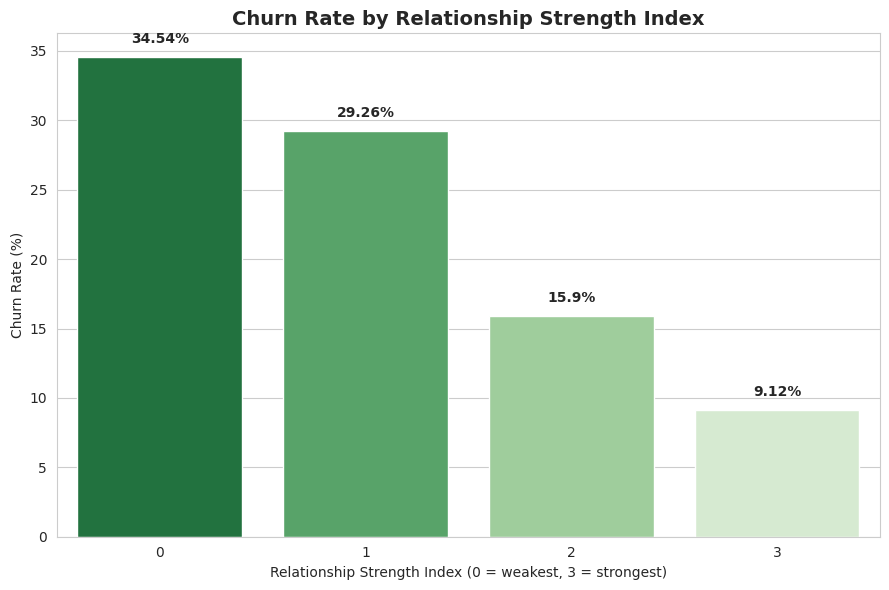

In [31]:
plt.figure(figsize=(9, 6))
ax = sns.barplot(x=rsi_summary.index, y=rsi_summary['ChurnRate(%)'], palette='Greens_r')

plt.title('Churn Rate by Relationship Strength Index', fontsize=14, fontweight='bold')
plt.xlabel('Relationship Strength Index (0 = weakest, 3 = strongest)')
plt.ylabel('Churn Rate (%)')

for i, value in enumerate(rsi_summary['ChurnRate(%)']):
    ax.text(i, value + 1, f'{value}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Consolidated KPI summary

The cell below collects all five KPI results into a single summary table, giving a single place to read every headline number produced by this notebook. This table will be the direct source for the Streamlit dashboard's summary panel, the research paper's KPI section, and the executive summary.

In [32]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Engagement Retention Ratio',
        'Product Depth Index',
        'High-Balance Disengagement Rate',
        'Credit Card Stickiness Score',
        'Relationship Strength Index (0 to 3 churn range)'
    ],
    'Value': [
        f'{engagement_retention_ratio:.2f}x',
        f'{product_depth_index:.2f}%',
        f'{high_balance_disengagement_rate:.2f}%',
        f'{credit_card_stickiness_score:.2f}%',
        f'{rsi_summary["ChurnRate(%)"].max():.2f}% down to {rsi_summary["ChurnRate(%)"].min():.2f}%'
    ]
})

kpi_summary

,KPI,Value
0,Engagement Retention Ratio,1.88x
1,Product Depth Index,72.64%
2,High-Balance Disengagement Rate,49.12%
3,Credit Card Stickiness Score,3.03%
4,Relationship Strength Index (0 to 3 churn range),34.54% down to 9.12%


### Phase 6 and notebook conclusion

The five KPIs confirm and quantify everything found across the earlier phases. The **Engagement Retention Ratio** of 1.88 means inactive customers churn nearly twice as often as active ones. The **Product Depth Index** of 72.64% shows that gaining a second product cuts churn risk dramatically, though this benefit is specific to moving from 1 to 2 products and does not extend to 3 or 4. The **High-Balance Disengagement Rate** of 49.12% is a striking exposure figure, meaning roughly half of the bank's above-median-balance customers are currently inactive. The **Credit Card Stickiness Score** of only 3.03% confirms that card ownership on its own is a weak retention lever, which is a useful negative finding, since it tells the bank not to over-invest in card-based retention campaigns in isolation. Finally, the **Relationship Strength Index** shows a clean, monotonic drop in churn from 34.54% at a score of 0 down to 9.12% at a score of 3, making it the single strongest and most complete indicator built in this notebook.

Together with the engagement profiles from Phase 2, the product depth findings from Phase 3, the balance and salary findings from Phase 4, and the stability and stickiness findings from Phase 5, this notebook now contains everything needed to build the three remaining deliverables: the Streamlit dashboard, the research paper, and the executive summary.